In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv(r"/content/Sleep_health_and_lifestyle_dataset.csv")

In [ ]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [ ]:
df.isnull().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


In [ ]:
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('Unknown')

In [ ]:
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,Unknown
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,Unknown
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,Unknown
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


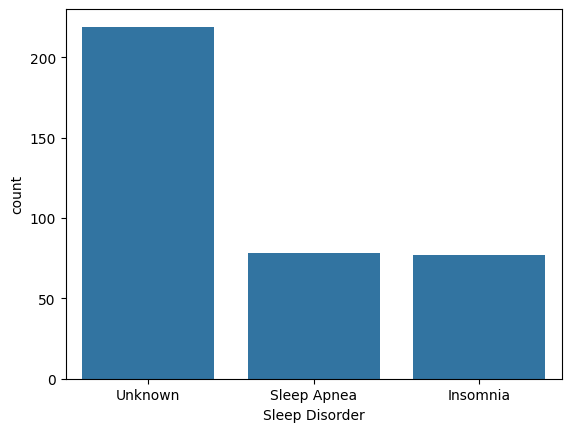

In [ ]:
# Countplot for target value
sns.countplot(x='Sleep Disorder', data = df)
plt.show()

In [ ]:
df = df.drop(columns =['Person ID'])

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

In [ ]:
cat_cols.remove('Sleep Disorder')

In [ ]:
df = pd.get_dummies(df, columns=cat_cols)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sleep Disorder'] = le.fit_transform(df['Sleep Disorder'])

In [ ]:
df

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Sleep Disorder,Gender_Female,Gender_Male,...,Blood Pressure_130/85,Blood Pressure_130/86,Blood Pressure_131/86,Blood Pressure_132/87,Blood Pressure_135/88,Blood Pressure_135/90,Blood Pressure_139/91,Blood Pressure_140/90,Blood Pressure_140/95,Blood Pressure_142/92
0,27,6.1,6,42,6,77,4200,2,False,True,...,False,False,False,False,False,False,False,False,False,False
1,28,6.2,6,60,8,75,10000,2,False,True,...,False,False,False,False,False,False,False,False,False,False
2,28,6.2,6,60,8,75,10000,2,False,True,...,False,False,False,False,False,False,False,False,False,False
3,28,5.9,4,30,8,85,3000,1,False,True,...,False,False,False,False,False,False,False,True,False,False
4,28,5.9,4,30,8,85,3000,1,False,True,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,59,8.1,9,75,3,68,7000,1,True,False,...,False,False,False,False,False,False,False,False,True,False
370,59,8.0,9,75,3,68,7000,1,True,False,...,False,False,False,False,False,False,False,False,True,False
371,59,8.1,9,75,3,68,7000,1,True,False,...,False,False,False,False,False,False,False,False,True,False
372,59,8.1,9,75,3,68,7000,1,True,False,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
X = df.drop(columns = ['Sleep Disorder'])
y = df['Sleep Disorder']

In [ ]:
from sklearn.model_selection  import train_test_split
# First split 80% training and 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Second split: divide temporary data set into 10% validation and 10% testing
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
df.shape

(374, 50)

In [ ]:
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_val = scaler.transform(X_val)
# X_test = scaler.transform(X_test)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
model = Sequential()

In [ ]:
# input layer
model.add(Dense(df.shape[1]))

In [ ]:
# nodes - 128,64,32,3
# Hidden Layer - 1
model.add(Dense(128, activation='relu'))


In [ ]:
# Hidden Layer - 2
model.add(Dense(64, activation='relu'))


In [ ]:
# Hidden Layer - 3
model.add(Dense(32, activation='relu'))

In [ ]:
# Hidden Layer - 4
model.add(Dense(3, activation='relu'))

In [ ]:
# Compile, fit, Callbacks
from tensorflow.keras.optimizers import Adam
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
metrics=['accuracy']),

(None,)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)

In [ ]:
model.fit(X_train, y_train, epochs=100, validation_data=(X_val, y_val), callbacks=[early_stop])

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.5886 - loss: 6.6305 - val_accuracy: 0.5405 - val_loss: 7.4056
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5886 - loss: 6.6305 - val_accuracy: 0.5405 - val_loss: 7.4056
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5886 - loss: 6.6305 - val_accuracy: 0.5405 - val_loss: 7.4056
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5886 - loss: 6.6305 - val_accuracy: 0.5405 - val_loss: 7.4056
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5886 - loss: 6.6305 - val_accuracy: 0.5405 - val_loss: 7.4056
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5886 - loss: 6.6305 - val_accuracy: 0.5405 - val_loss: 7.4056
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5886 - loss: 6.6305 - val_accuracy: 0.5405 - val_loss: 7.4056
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5886 - loss: 6.6305 - val_accuracy: 0.5405 - 

In [ ]:
# evaluation
loss, accuracy = model.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6053 - loss: 6.3624


In [ ]:
loss

6.362406253814697

In [ ]:
accuracy

0.6052631735801697

In [ ]:
model.save('sleep_disorder_model.h5')